# Expected Goals -- Distance

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    log_loss,
    brier_score_loss,
    roc_auc_score
)

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from src.data.split_data import train_test_split_by_match
from src.visualization.plot_xg_surface import plot_xg_surface
from src.visualization.plot_calibration import plot_calibration

In [17]:
df = pd.read_csv("../../data/processed/shots.csv")

df.head()

,match_id,period,minute,second,team,player,x,y,goal,body_part,...,first_time,aerial_won,one_on_one,deflected,open_goal,saved_off_target,redirect,saved_to_post,follows_dribble,statsbomb_xg
0,3754300,1,12,14,Watford,Troy Deeney,108.9,40.6,0,Right Foot,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.085717
1,3754300,1,12,52,Watford,Troy Deeney,94.7,34.4,0,Right Foot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023742
2,3754300,1,12,58,Watford,Miguel Arturo Layún Prado,107.4,41.7,1,Right Foot,...,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.148063
3,3754300,1,18,16,Everton,Gareth Barry,111.8,40.2,0,Head,...,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.074549
4,3754300,1,23,14,Everton,Ross Barkley,96.5,39.7,0,Right Foot,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036574


## Model 1 -- Shot Distance

The baseline model gives every shot the same probability of scoring.

A natural first improvement is to account for **shot location**. Intuitively,
shots closer to the goal should have a higher probability of resulting in a goal.

We therefore build a model using only the distance between the shot location
and the center of the goal.

StatsBomb uses a $120 \times 80$ pitch, with the attacking goal centered at
$(120,40)$.

For a shot at coordinates $(x_i,y_i)$, the distance to the center of the goal is:

$$
d_i =
\sqrt{(120-x_i)^2 + (40-y_i)^2}
$$

We then model the probability of scoring as a function of distance:

$$
P(Y_i=1 \mid d_i)
=
\frac{1}
{1+\exp\left(-(\beta_0+\beta_1d_i)\right)}
$$

where $\beta_0$ and $\beta_1$ are estimated from the data.

In [19]:
df["distance"] = np.sqrt(
    (120 - df["x"])**2 +
    (40 - df["y"])**2
)

df[["x", "y", "distance"]].head()

,x,y,distance
0,108.9,40.6,11.116204
1,94.7,34.4,25.912352
2,107.4,41.7,12.714165
3,111.8,40.2,8.202439
4,96.5,39.7,23.501915


In [20]:
df["distance"].describe()

count    9908.000000
mean       19.071931
std         8.291229
min         0.921954
25%        12.126417
50%        18.791620
75%        25.339840
max        86.137100
Name: distance, dtype: float64

Before fitting the model, we can examine how the observed scoring rate
changes with shot distance.

In [21]:
df["distance_bin"] = pd.cut(
    df["distance"],
    bins=np.arange(0, 61, 5)
)

distance_summary = (
    df.groupby("distance_bin", observed=False)
      .agg(
          shots=("goal", "size"),
          goals=("goal", "sum"),
          scoring_rate=("goal", "mean")
      )
      .reset_index()
)

distance_summary

,distance_bin,shots,goals,scoring_rate
0,"(0, 5]",163,69,0.423313
1,"(5, 10]",1394,281,0.201578
2,"(10, 15]",1950,324,0.166154
3,"(15, 20]",1892,164,0.086681
4,"(20, 25]",1907,83,0.043524
5,"(25, 30]",1683,48,0.028520
6,"(30, 35]",730,15,0.020548
7,"(35, 40]",139,3,0.021583
8,"(40, 45]",24,1,0.041667
9,"(45, 50]",5,0,0.000000


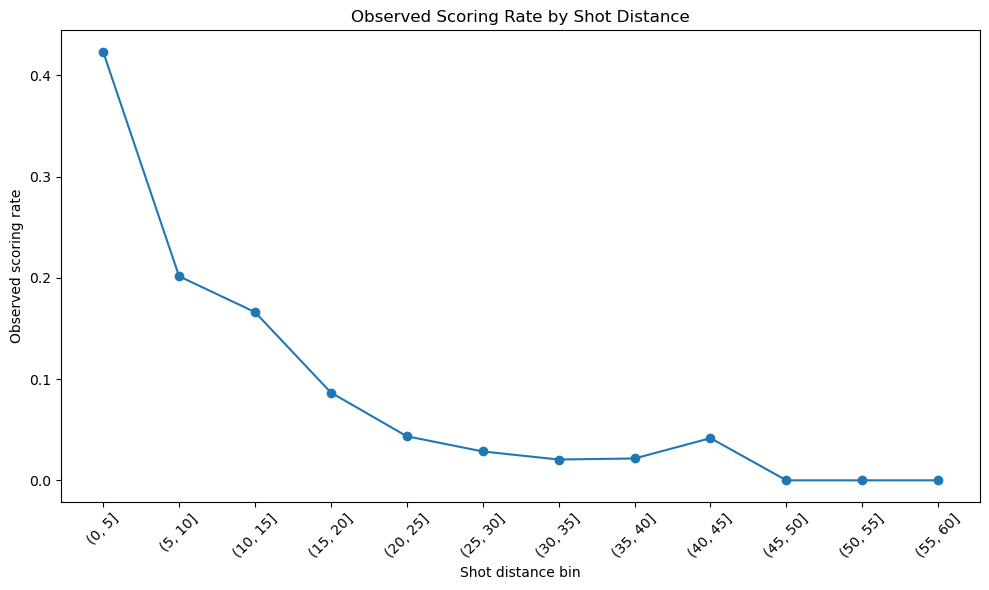

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    distance_summary["distance_bin"].astype(str),
    distance_summary["scoring_rate"],
    marker="o"
)

plt.xlabel("Shot distance bin")
plt.ylabel("Observed scoring rate")
plt.title("Observed Scoring Rate by Shot Distance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Train-test split

To evaluate the model out of sample, we separate matches into training
and test sets.

All shots from a given match remain in the same split.

In [23]:
train, test = train_test_split_by_match(
    df,
    test_size=0.2,
    random_state=42
)

print(f"Training shots: {len(train):,}")
print(f"Test shots:     {len(test):,}")

Training shots: 7,824
Test shots:     2,084


In [24]:
print(f"Training matches: {train['match_id'].nunique()}")
print(f"Test matches:     {test['match_id'].nunique()}")

Training matches: 304
Test matches:     76


### Fitting the model

We use logistic regression to estimate the relationship between shot
distance and the probability of scoring.

In [25]:
X_train = train[["distance"]]
y_train = train["goal"]

X_test = test[["distance"]]
y_test = test["goal"]

model_distance = LogisticRegression()

model_distance.fit(X_train, y_train)

LogisticRegression()

In [26]:
print(f"Intercept:  {model_distance.intercept_[0]:.4f}")
print(f"Coefficient: {model_distance.coef_[0][0]:.4f}")

Intercept:  -0.2289
Coefficient: -0.1189


We expect the coefficient to be negative: greater distance should generally mean a lower probability of scoring.

### Generate xG predictions

In [27]:
test["xg_distance"] = model_distance.predict_proba(
    X_test
)[:, 1]

test[["distance", "goal", "xg_distance"]].head(10)

,distance,goal,xg_distance
0,11.116204,0,0.175011
1,25.912352,0,0.035242
2,12.714165,1,0.149249
3,8.202439,0,0.230746
4,23.501915,0,0.046395
5,28.756391,0,0.025388
6,25.420071,0,0.037287
7,27.895878,0,0.028046
8,26.184156,0,0.034160
9,7.736924,0,0.240716


### Evaluation

In [28]:
logloss_distance = log_loss(
    y_test,
    test["xg_distance"]
)

brier_distance = brier_score_loss(
    y_test,
    test["xg_distance"]
)

auc_distance = roc_auc_score(
    y_test,
    test["xg_distance"]
)

print(f"Log Loss:    {logloss_distance:.4f}")
print(f"Brier Score: {brier_distance:.4f}")
print(f"ROC AUC:     {auc_distance:.4f}")

Log Loss:    0.2667
Brier Score: 0.0750
ROC AUC:     0.7398


## Model Comparison

Model 1 substantially improves upon the constant-probability baseline.

| Model | Log Loss | Brier Score | ROC AUC |
|---|---:|---:|---:|
| Constant probability | 0.2967 | 0.0796 | 0.500 |
| Distance | 0.2667 | 0.0750 | 0.7398 |

Adding shot distance allows the model to distinguish between high- and
low-quality shot locations, resulting in substantially better
out-of-sample predictions.

## Visualization

In [29]:
def predict_distance_xg(x, y):

    distance = np.sqrt(
        (120 - x)**2 +
        (40 - y)**2
    )

    X = pd.DataFrame({
        "distance": distance
    })

    return model_distance.predict_proba(X)[:, 1]

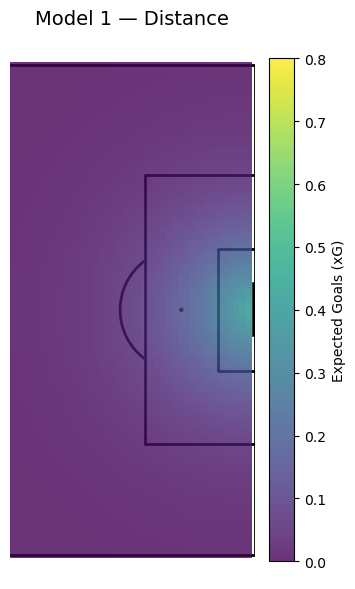

In [15]:
fig, ax = plot_xg_surface(
    predict_distance_xg,
    title="Model 1 — Distance",
    save_path="../../reports/figures/xg_surfaces/model_1_distance.png"
)

(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Calibration — Model 1 — Distance'}, xlabel='Predicted xG', ylabel='Observed Goal Rate'>)

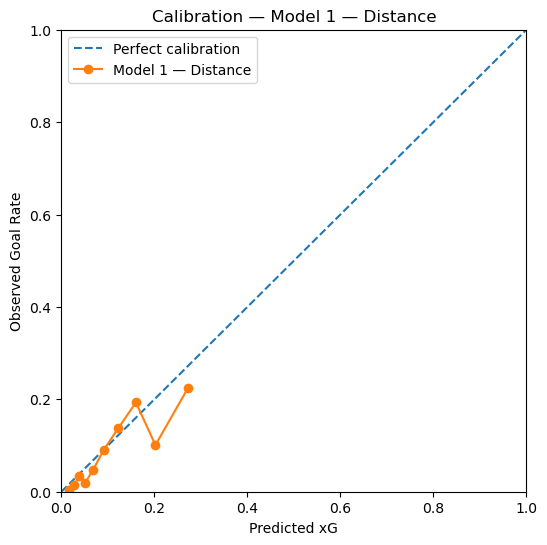

In [30]:
plot_calibration(
    y_test,
    test["xg_distance"],
    model_name="Model 1 — Distance",
    save_path="../../reports/figures/calibration/model_1_calibration.png"
)